# Aula 1 · Intro a ML + Regressão Linear

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlexChequer/notebooks-insperai/blob/main/trainees/aula-01-regressao-linear.ipynb)

**Trilha de Trainees — InsperAI** · o par prático da [Aula 1](https://trilhas-insperai.vercel.app/trainees/aulas/aula-01/)

---

Na página da aula você mexeu nos sliders de $w$ e $b$ e viu o custo mudar. Aqui é a
mesma coisa, com dado real e você escrevendo as contas.

O ciclo é o mesmo da aula, e é o do curso inteiro:

1. escolher um **modelo** (uma reta),
2. medir o quanto ele **erra** (o custo),
3. **ajustar** o modelo para errar menos (gradient descent).

O dado são **1.460 imóveis reais** vendidos em Ames, Iowa. É o mesmo exemplo da
página — prever **preço** a partir da **metragem** —, agora com números que
alguém mediu de verdade.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Local, o arquivo está na pasta dados/ — mas o caminho depende de onde o Jupyter
# foi aberto (na raiz do repo ou dentro de trainees/). No Colab não existe nenhum
# dos dois, e aí ele é baixado do GitHub.
CANDIDATOS = ["dados/imoveis.csv", "../dados/imoveis.csv"]
URL = "https://raw.githubusercontent.com/AlexChequer/notebooks-insperai/main/dados/imoveis.csv"

imoveis = pd.read_csv(next((c for c in CANDIDATOS if os.path.exists(c)), URL))

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"{len(imoveis)} imóveis, {imoveis.shape[1]} colunas")
imoveis.head()

1460 imóveis, 8 colunas


,metragem_m2,terreno_m2,quartos,banheiros,vagas_garagem,qualidade,idade_anos,preco_mil
0,158.9,785.0,3,2,2,7,5,208.5
1,117.2,891.9,3,2,2,6,31,181.5
2,165.9,1045.2,3,2,2,7,7,223.5
3,159.5,887.2,3,1,3,7,91,140.0
4,204.2,1324.8,4,2,3,8,8,250.0


## 1 · O dado

Nesta aula vamos usar duas colunas só — uma entrada e uma resposta —, porque com
duas dá para desenhar tudo num gráfico e enxergar cada peça. A Aula 2 usa o resto.

- `metragem_m2` → é o **$x$**, a *feature* (a entrada)
- `preco_mil` → é o **$y$**, a resposta que queremos prever (em milhares de dólares)

In [2]:
metragem = imoveis["metragem_m2"].to_numpy()
preco = imoveis["preco_mil"].to_numpy()

print(f"metragem: de {metragem.min():.0f} a {metragem.max():.0f} m²  (mediana {np.median(metragem):.0f})")
print(f"preço:    de {preco.min():.0f} a {preco.max():.0f} mil  (mediana {np.median(preco):.0f})")

metragem: de 31 a 524 m²  (mediana 136)
preço:    de 35 a 755 mil  (mediana 163)


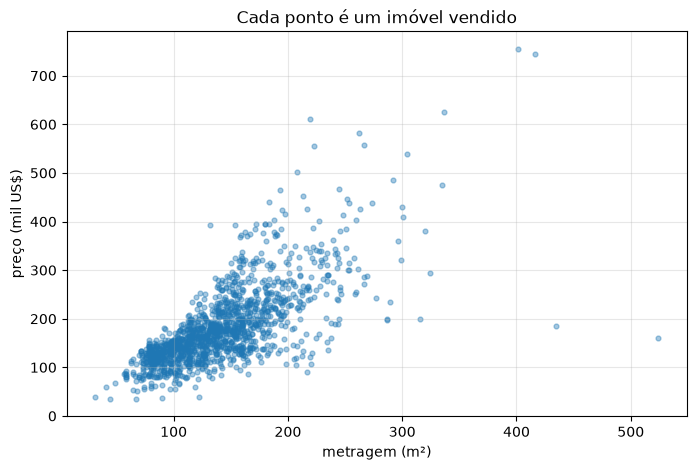

In [3]:
plt.scatter(metragem, preco, s=12, alpha=0.4)
plt.xlabel("metragem (m²)")
plt.ylabel("preço (mil US$)")
plt.title("Cada ponto é um imóvel vendido")
plt.show()

Repare que os pontos **não** formam uma reta — eles formam uma *tendência*. Se
formassem uma reta perfeita, não haveria nada para aprender: bastava ligar dois
pontos.

> **"Linear" descreve o formato do modelo, não o formato dos dados.** É o primeiro
> erro comum da aula.

## 2 · O modelo é uma reta

O modelo mais simples que existe:

$$\text{previsão} = w \cdot x + b$$

- $w$ (inclinação) — quanto o preço sobe a cada m² a mais
- $b$ (deslocamento) — a altura em que a reta começa

**Ajustar o modelo é escolher $w$ e $b$.** Só isso. Vamos chutar valores primeiro.

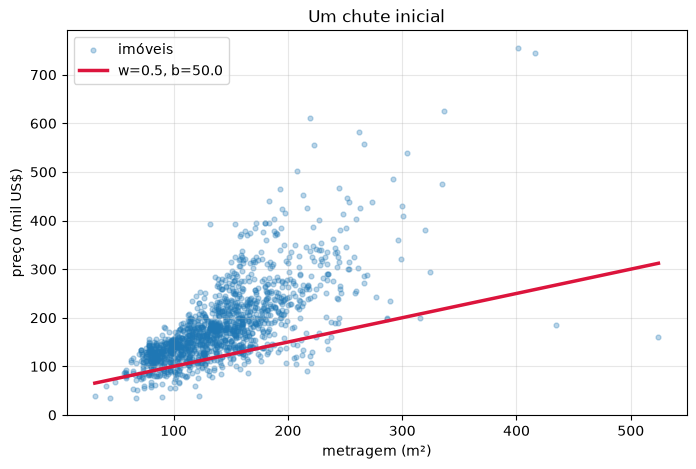

In [4]:
def prever(x, w, b):
    """O modelo inteiro, numa linha."""
    return w * x + b


# Um chute qualquer, para começar
w, b = 0.5, 50.0

linha_x = np.array([metragem.min(), metragem.max()])
plt.scatter(metragem, preco, s=12, alpha=0.3, label="imóveis")
plt.plot(linha_x, prever(linha_x, w, b), color="crimson", lw=2.5, label=f"w={w}, b={b}")
plt.xlabel("metragem (m²)")
plt.ylabel("preço (mil US$)")
plt.legend()
plt.title("Um chute inicial")
plt.show()

🔬 **Experimente:** volte na célula acima, troque `w` e `b`, e rode de novo. É o
slider da página da aula, na mão.

## 3 · O erro de cada imóvel: os resíduos

Para cada imóvel, o modelo dá um palpite e a gente compara com o preço real. A
diferença é o **resíduo** — a distância **vertical** entre o ponto e a reta.

É vertical porque o que o modelo errou foi o **preço**. A metragem é um dado, não
um chute: ela está certa.

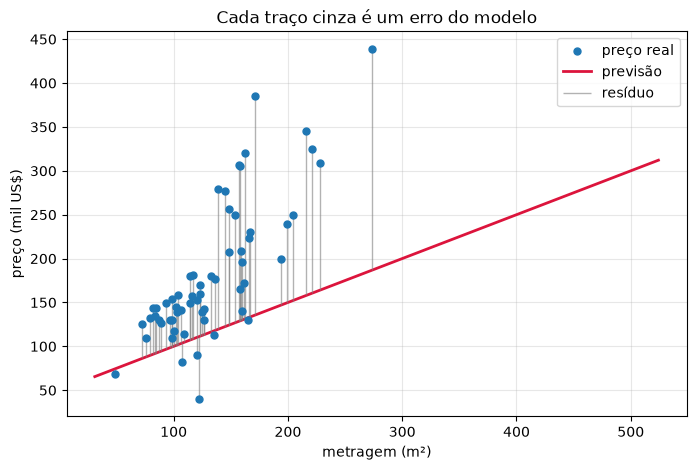

resíduo médio (com sinal):     60.5
maior erro para menos:        504.5
maior erro para mais:        -152.1


In [5]:
residuos = preco - prever(metragem, w, b)

# Desenha só os 60 primeiros, senão o gráfico vira um borrão
amostra = slice(0, 60)
plt.scatter(metragem[amostra], preco[amostra], s=25, zorder=3, label="preço real")
plt.plot(linha_x, prever(linha_x, w, b), color="crimson", lw=2, label="previsão")
plt.vlines(metragem[amostra], prever(metragem[amostra], w, b), preco[amostra],
           color="gray", alpha=0.6, lw=1, label="resíduo")
plt.xlabel("metragem (m²)")
plt.ylabel("preço (mil US$)")
plt.legend()
plt.title("Cada traço cinza é um erro do modelo")
plt.show()

print(f"resíduo médio (com sinal): {residuos.mean():>8.1f}")
print(f"maior erro para menos:     {residuos.max():>8.1f}")
print(f"maior erro para mais:      {residuos.min():>8.1f}")

## 4 · O custo: resumir todos os erros num número

Somar os resíduos com sinal não serve: os positivos cancelam os negativos, e o
total dá quase zero **mesmo numa reta péssima**. Para escapar disso, eleva-se cada
resíduo ao quadrado (o que apaga o sinal) e tira-se a média.

Esse número é o **custo**:

$$J(w, b) = \frac{1}{n}\sum_{i=1}^{n}\bigl(y_i - (w x_i + b)\bigr)^2$$

> **Custo não é o erro de uma previsão.** O erro de um imóvel é o resíduo dele; o
> custo resume o conjunto **inteiro**. Trocar um pelo outro é o tropeço mais comum
> da aula.

In [6]:
def custo(x, y, w, b):
    """Erro quadrático médio: o resumo do erro no conjunto inteiro."""
    return np.mean((y - prever(x, w, b)) ** 2)


def soma_com_sinal(x, y, w, b):
    """A forma ingênua de somar erros — a que não funciona."""
    return np.sum(y - prever(x, w, b))


# Duas retas MUITO diferentes. A segunda ignora a metragem por completo:
# ela chuta o preço médio para qualquer imóvel, o que é péssimo.
reta_boa = (1.15, 19.0)
reta_burra = (0.0, preco.mean())

print(f"{'':<28}{'soma com sinal':>16}{'custo':>12}")
for nome, (cw, cb) in [("reta ajustada", reta_boa), ("chutar sempre a média", reta_burra)]:
    print(f"{nome:<28}{soma_com_sinal(metragem, preco, cw, cb):>16.1f}{custo(metragem, preco, cw, cb):>12.1f}")

                              soma com sinal       custo
reta ajustada                           16.7      3140.0
chutar sempre a média                   -0.0      6306.9


As duas somas com sinal dão praticamente **zero** — e as duas retas são
completamente diferentes: uma usa a metragem, a outra a ignora e chuta sempre a
média. A soma com sinal não distingue as duas; o custo separa na hora.

É por isso que se eleva ao quadrado: o sinal carrega a *direção* do erro, não o
*tamanho*. Apagar o sinal é o que faz erros para cima e para baixo pararem de se
anular.

Agora que existe uma régua, treinar vira procurar o par $(w, b)$ de menor custo:

In [7]:
chutes = [(0.5, 50), (1.0, 20), (1.5, 0), (1.15, 19)]

for cw, cb in chutes:
    print(f"w={cw:<5} b={cb:<4} → custo {custo(metragem, preco, cw, cb):>8.1f}")

w=0.5   b=50   → custo   7819.4
w=1.0   b=20   → custo   3601.1
w=1.5   b=0    → custo   4342.5
w=1.15  b=19   → custo   3140.0


O último chute é bem melhor que o primeiro. Mas testar na mão não escala — é para
isso que existe o gradient descent, daqui a duas seções.

## 5 · MAE, MSE e RMSE

Elevar ao quadrado não é a única forma de resumir o erro:

| medida | conta | comportamento |
|---|---|---|
| **MAE** | média de $\lvert$resíduo$\rvert$ | erro de 10 pesa 10× um erro de 1 |
| **MSE** | média do resíduo² | erro de 10 pesa **100×** um erro de 1 |
| **RMSE** | $\sqrt{\text{MSE}}$ | volta à unidade original — dá para interpretar |

A diferença aparece com um **outlier**. Vamos criar um: um imóvel pequeno vendido
por um preço absurdo.

In [8]:
def mae(x, y, w, b):
    return np.mean(np.abs(y - prever(x, w, b)))


def mse(x, y, w, b):
    return np.mean((y - prever(x, w, b)) ** 2)


def rmse(x, y, w, b):
    return np.sqrt(mse(x, y, w, b))


w_bom, b_bom = 1.15, 19.0


def comparar_com_outlier(x, y, rotulo):
    """Acrescenta UM imóvel de 60 m² vendido por 2 milhões e mede o estrago."""
    x_out = np.append(x, 60.0)
    y_out = np.append(y, 2000.0)

    print(f"\n{rotulo}  ({len(x)} imóveis)")
    print(f"{'':<8}{'sem outlier':>14}{'com outlier':>14}{'variação':>12}")
    for nome, f in [("MAE", mae), ("MSE", mse), ("RMSE", rmse)]:
        sem = f(x, y, w_bom, b_bom)
        com = f(x_out, y_out, w_bom, b_bom)
        print(f"{nome:<8}{sem:>14.1f}{com:>14.1f}{com / sem:>11.1f}×")


comparar_com_outlier(metragem, preco, "Conjunto inteiro")
comparar_com_outlier(metragem[:40], preco[:40], "Só os 40 primeiros")


Conjunto inteiro  (1460 imóveis)
           sem outlier   com outlier    variação
MAE               37.6          38.9        1.0×
MSE             3140.0        5640.1        1.8×
RMSE              56.0          75.1        1.3×

Só os 40 primeiros  (40 imóveis)
           sem outlier   com outlier    variação
MAE               36.5          82.3        2.3×
MSE             2454.6       91559.2       37.3×
RMSE              49.5         302.6        6.1×


Duas coisas aparecem aí.

**O quadrado castiga o extremo.** Em qualquer um dos dois conjuntos, o MSE reage
muito mais forte que o MAE ao mesmo imóvel esquisito. É a consequência direta de
elevar ao quadrado: um erro de 10 pesa 100 vezes um erro de 1.

**E o tamanho do conjunto dilui.** Com 1.460 imóveis, um outlier é 1/1461 da média
e mal aparece; com 40, ele domina a conta. Um número de erro sempre depende de
quantos exemplos entraram nele — vale desconfiar de métrica sem o $n$ ao lado.

**A moral prática:** se um erro grande é catastrófico no seu problema, use MSE,
que castiga outlier com força. Se o dado tem ruído grosso e um ponto fora da curva
de vez em quando não é o fim do mundo, o MAE é mais robusto.

## 6 · Gradient descent: achar o fundo da tigela

Para **cada** par $(w, b)$ existe um custo. Se $w$ for um eixo, $b$ outro, e a
altura for o custo, isso desenha uma superfície em forma de **tigela**. O ponto
mais fundo é o melhor modelo.

Para descer, usa-se a derivada: ela diz a inclinação do custo em relação a cada
parâmetro. O gradiente aponta para a **subida** mais íngreme, então anda-se no
sentido contrário:

$$w \leftarrow w - \alpha\frac{\partial J}{\partial w}, \qquad b \leftarrow b - \alpha\frac{\partial J}{\partial b}$$

Derivando o custo lá de cima:

$$\frac{\partial J}{\partial w} = -\frac{2}{n}\sum x_i\,(y_i - \hat{y}_i), \qquad \frac{\partial J}{\partial b} = -\frac{2}{n}\sum (y_i - \hat{y}_i)$$

São essas duas linhas que viram código:

In [9]:
def gradient_descent(x, y, alfa, iteracoes, w=0.0, b=0.0):
    """Treina o modelo. Devolve os parâmetros finais e o custo de cada iteração."""
    historico = []

    for _ in range(iteracoes):
        residuo = y - prever(x, w, b)
        historico.append(np.mean(residuo ** 2))

        # As duas derivadas da fórmula acima
        derivada_w = -2 * np.mean(x * residuo)
        derivada_b = -2 * np.mean(residuo)

        # O passo: anda no sentido contrário ao gradiente
        w = w - alfa * derivada_w
        b = b - alfa * derivada_b

    return w, b, np.array(historico)


w_treino, b_treino, historico = gradient_descent(metragem, preco, alfa=2e-5, iteracoes=300)

print(f"w = {w_treino:.4f}   b = {b_treino:.2f}")
print(f"custo no começo: {historico[0]:>8.1f}")
print(f"custo no fim:    {historico[-1]:>8.1f}")

w = 1.2707   b = 0.03
custo no começo:  39039.6
custo no fim:      3176.8


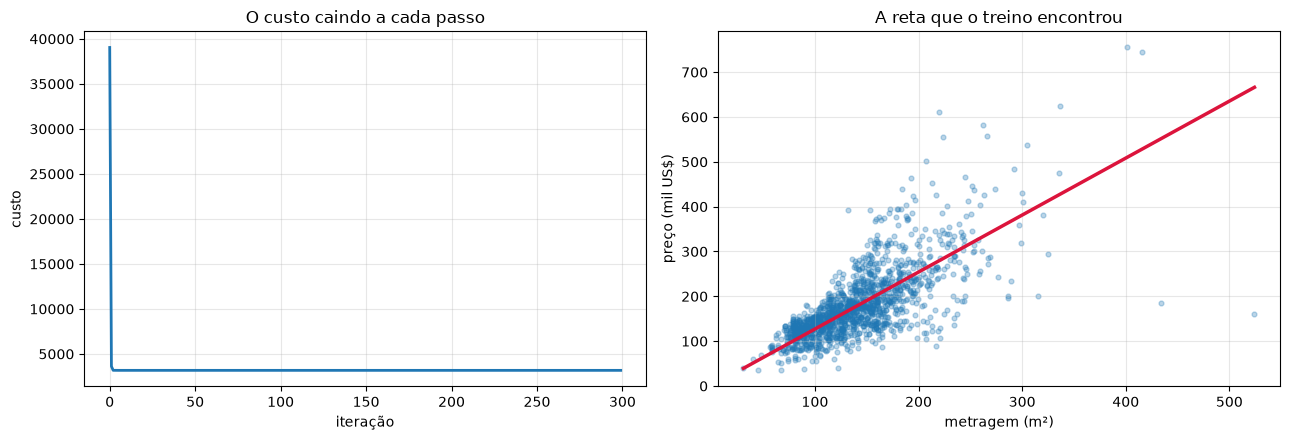

In [10]:
fig, (esq, dir) = plt.subplots(1, 2, figsize=(13, 4.5))

esq.plot(historico, lw=2)
esq.set_xlabel("iteração")
esq.set_ylabel("custo")
esq.set_title("O custo caindo a cada passo")

dir.scatter(metragem, preco, s=12, alpha=0.3)
dir.plot(linha_x, prever(linha_x, w_treino, b_treino), color="crimson", lw=2.5)
dir.set_xlabel("metragem (m²)")
dir.set_ylabel("preço (mil US$)")
dir.set_title(f"A reta que o treino encontrou")

plt.tight_layout()
plt.show()

> **O gradiente não é a resposta** — é só uma **direção**, válida ali onde você
> está. Ele não sabe onde fica o fundo da tigela nem quanto falta. Por isso o
> treino é um monte de passos pequenos, e não uma conta só.

## 7 · O learning rate ($\alpha$)

O $\alpha$ é o tamanho do passo, e é o **primeiro hiperparâmetro** do curso: um
número que **você** escolhe, ao contrário de $w$ e $b$, que o modelo aprende.

Ele é um equilíbrio delicado. Vamos ver os três regimes no nosso dado:

α = 1e-07    (pequeno demais ) → custo final: 5681.4
α = 2e-05    (bom            ) → custo final: 3176.8
α = 5e-05    (grande demais  ) → custo final: 198712059667113911396506516025812943061479901055858769920.0


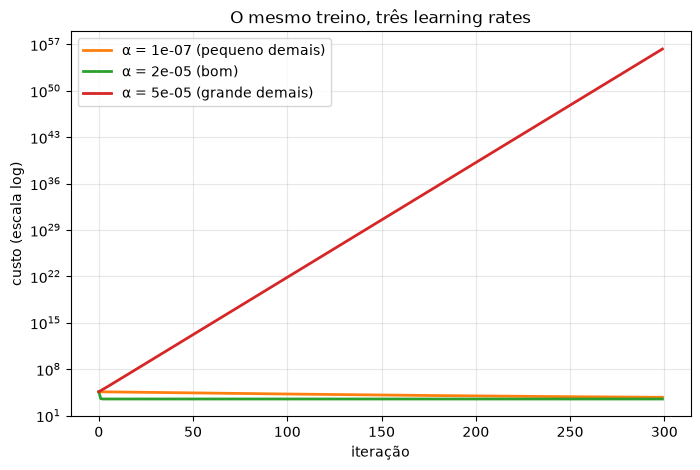

In [11]:
regimes = [
    ("pequeno demais", 1e-7, "tab:orange"),
    ("bom", 2e-5, "tab:green"),
    ("grande demais", 5e-5, "tab:red"),
]

for nome, alfa, cor in regimes:
    _, _, hist = gradient_descent(metragem, preco, alfa=alfa, iteracoes=300)
    final = hist[-1]
    estado = "explodiu" if not np.isfinite(final) else f"{final:.1f}"
    print(f"α = {alfa:<8} ({nome:<15}) → custo final: {estado}")
    plt.plot(hist, label=f"α = {alfa} ({nome})", color=cor, lw=2)

plt.yscale("log")  # sem escala log, a curva que explode achata as outras duas
plt.xlabel("iteração")
plt.ylabel("custo (escala log)")
plt.legend()
plt.title("O mesmo treino, três learning rates")
plt.show()

- **Grande demais**: cada passo ultrapassa o fundo e para mais longe do outro lado.
  O erro **explode** — repare que a curva vermelha sobe até estourar o número.
- **Pequeno demais**: o treino até anda na direção certa, mas leva uma eternidade.
- **No ponto**: desce rápido e estável.

🔬 **Experimente:** troque `2e-5` por `4e-5` na lista acima. Ainda converge? E com
`4.6e-5`? Existe um limite exato — e ele depende da escala dos seus dados, que é o
assunto da Aula 2.

## 8 · Conferindo com o scikit-learn

Tudo o que fizemos à mão existe pronto numa biblioteca. Vale comparar — e o
resultado traz uma surpresa.

In [12]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression().fit(metragem.reshape(-1, 1), preco)
w_sklearn, b_sklearn = modelo.coef_[0], modelo.intercept_

print(f"{'':<22}{'w':>10}{'b':>10}{'custo':>12}")
print(f"{'nosso treino':<22}{w_treino:>10.4f}{b_treino:>10.2f}{custo(metragem, preco, w_treino, b_treino):>12.1f}")
print(f"{'scikit-learn':<22}{w_sklearn:>10.4f}{b_sklearn:>10.2f}{custo(metragem, preco, w_sklearn, b_sklearn):>12.1f}")

                               w         b       custo
nosso treino              1.2707      0.03      3176.8
scikit-learn              1.1532     18.57      3140.0


O custo dos dois é quase igual, e o $w$ também. Mas olhe o **$b$**: o nosso ficou
perto de zero, e o do scikit-learn deu cerca de 19.

Não é bug. O $b$ está andando **muito mais devagar** que o $w$, porque a metragem
vale na casa das centenas e o $b$ é somado direto ao preço — as duas direções da
tigela têm inclinações muito diferentes, e ela deixou de ser redonda.

**Esse é exatamente o problema que a Aula 2 resolve**, com o nome de *escala das
features*. Guarde a pergunta: por que uma direção anda rápido e a outra se arrasta?

---

## 🔬 Desafio

Três exercícios. Tente antes de abrir a resposta.

**1.** Escreva uma função `preco_previsto(m2)` que use o modelo do scikit-learn
para prever o preço de um imóvel de qualquer metragem, e descubra quanto ele
prevê para **150 m²**.

<details><summary>Resposta</summary>

```python
def preco_previsto(m2):
    return float(modelo.predict(np.array([[m2]]))[0])

print(f"150 m² → US$ {preco_previsto(150):.1f} mil")
```

Repare que o modelo aceita qualquer número — inclusive 10.000 m², para o que ele
devolve um preço sem nenhum sentido. Prever fora da faixa em que se treinou
(*extrapolação*) é uma das formas mais fáceis de se enganar com um modelo.
</details>

**2.** O RMSE do nosso modelo é de mais ou menos 56 mil dólares. Isso é bom ou
ruim? Compare com um "modelo" que ignora a metragem e **chuta sempre o preço
médio**. Qual o RMSE dele?

<details><summary>Resposta</summary>

```python
rmse_modelo = rmse(metragem, preco, w_sklearn, b_sklearn)
rmse_media = np.sqrt(np.mean((preco - preco.mean()) ** 2))

print(f"nosso modelo:      {rmse_modelo:.1f}")
print(f"chutar sempre a média: {rmse_media:.1f}")
print(f"melhora: {(1 - rmse_modelo / rmse_media) * 100:.0f}%")
```

Sempre compare seu modelo com o palpite mais burro possível. "RMSE de 56" não quer
dizer nada sozinho; "29% melhor que chutar a média" quer.
</details>

**3.** Treine de novo com `gradient_descent`, mas começando de `w=3.0, b=100.0` em
vez de zero. O treino chega no mesmo lugar? Em quantas iterações?

<details><summary>Resposta</summary>

```python
w2, b2, hist2 = gradient_descent(metragem, preco, alfa=2e-5, iteracoes=300, w=3.0, b=100.0)
print(f"de (0, 0):     w={w_treino:.4f}  b={b_treino:.2f}")
print(f"de (3, 100):   w={w2:.4f}  b={b2:.2f}")
```

O $w$ chega no mesmo valor: a tigela tem um fundo só, e de qualquer ponto de partida
se desce para ele. O $b$ continua preso perto de onde começou — de novo o problema
de escala, que a Aula 2 explica.
</details>

---

## O que ficou

- Um **modelo** é um chute de formato: aqui, uma reta com dois parâmetros.
- O **custo** resume o erro do conjunto inteiro num número só.
- **MAE, MSE e RMSE** pesam os erros de formas diferentes — a escolha é sua e muda
  o modelo que você obtém.
- O **gradient descent** acha os parâmetros descendo a tigela em passos pequenos,
  e o **learning rate** é o tamanho do passo.

**Próximo:** [Aula 2 — Escalando o Modelo](https://colab.research.google.com/github/AlexChequer/notebooks-insperai/blob/main/trainees/aula-02-escalando-o-modelo.ipynb),
onde o vetor de entrada ganha mais features e o mistério do $b$ é resolvido.